In [65]:
#1. data understending
#menejlaskan sumber dataset
#dataset yang saya punya saya ambil dari kaggle dataset
#menjelaskan fitur/variabel dataset
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('/content/Crop_recommendation (1).csv')
df.head(10)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [67]:
#menampilkan statistik deskriptif data
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [68]:
#2. data prepsocesing
#- menangani missing value
# Cek missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


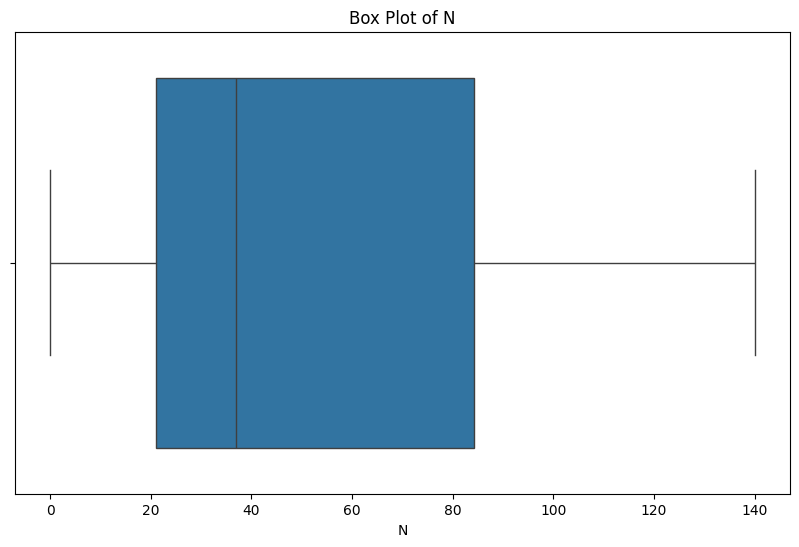

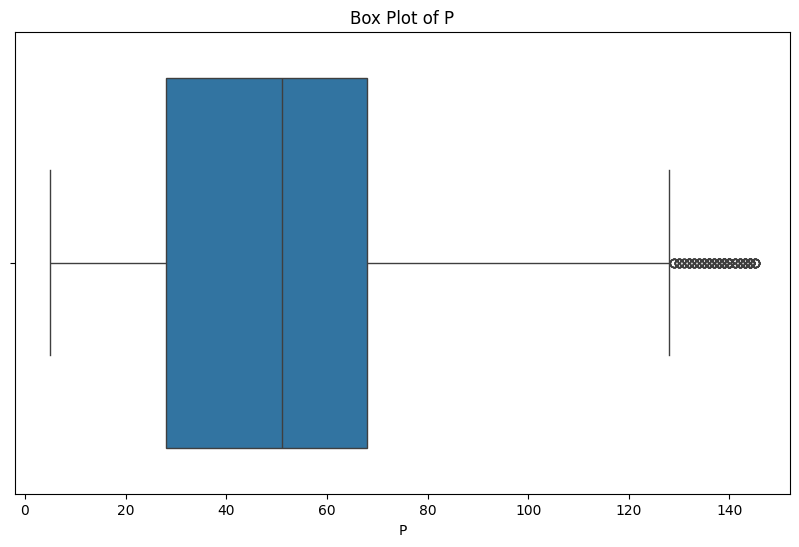

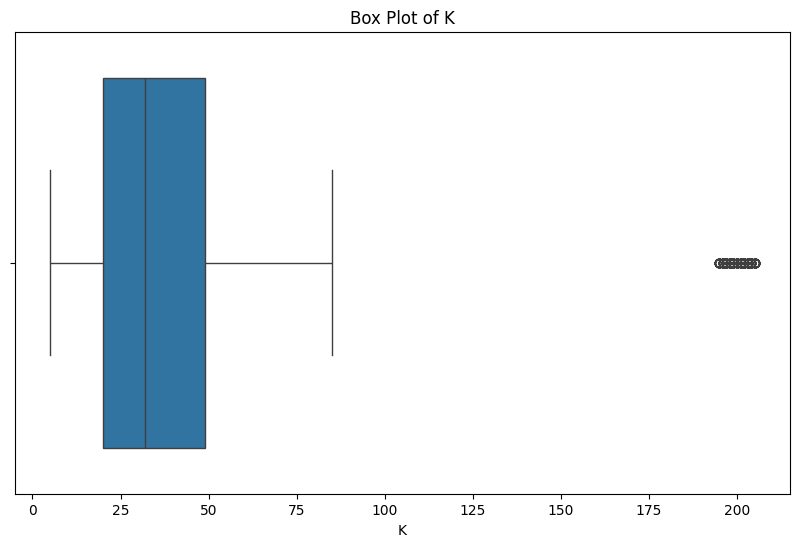

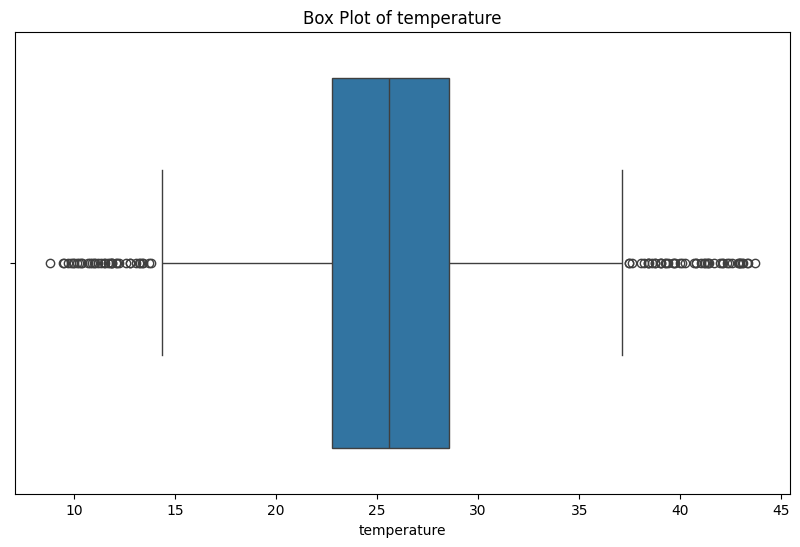

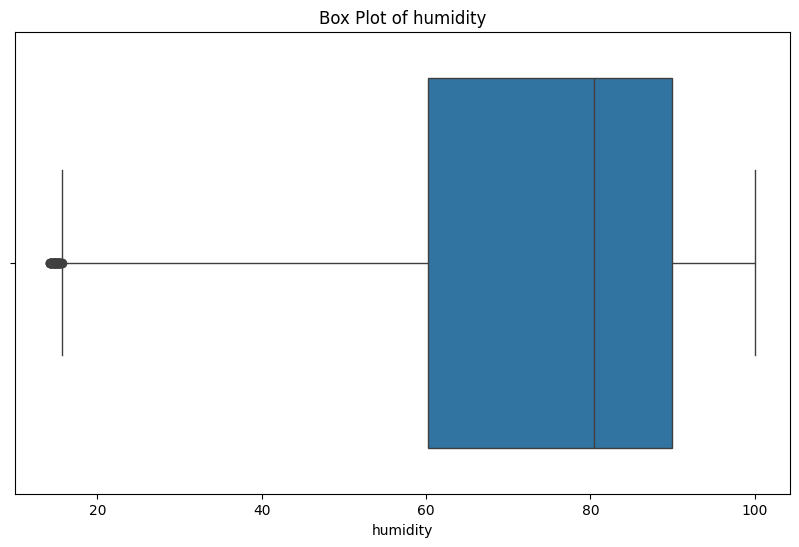

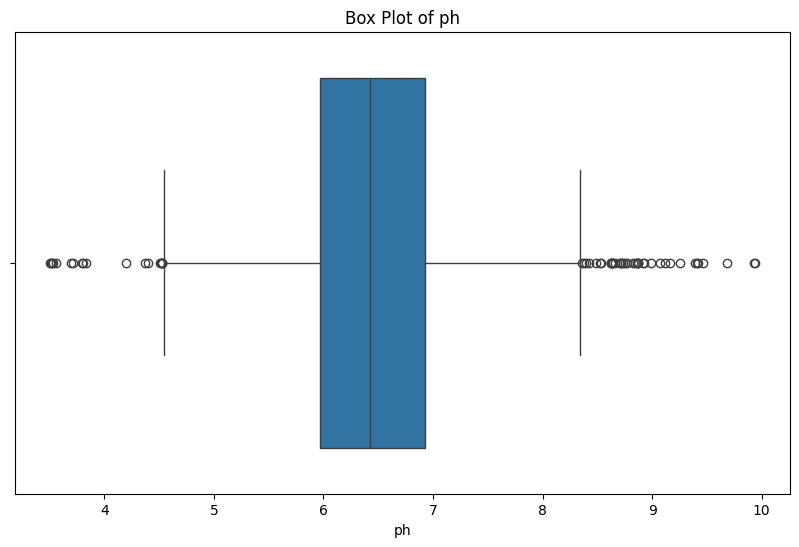

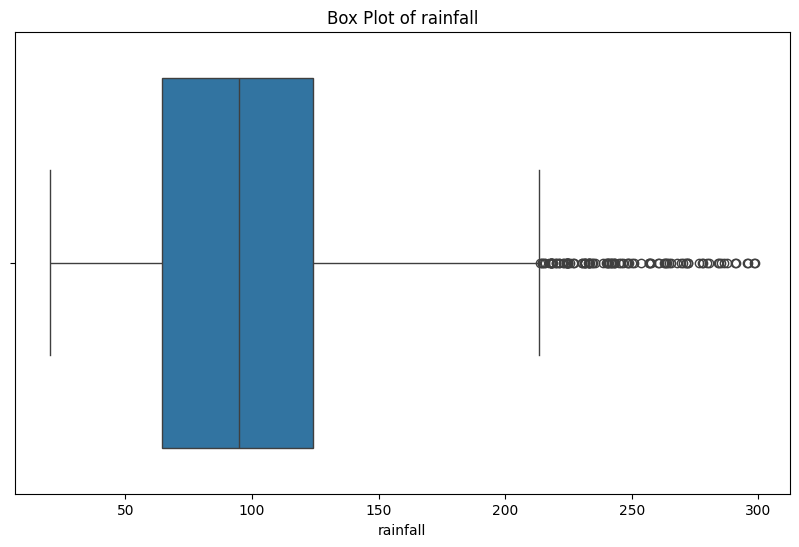

In [69]:
#- outlier, kita deteksi dulu apakah ada outlier atau tidak
import matplotlib.pyplot as plt
import seaborn as sns

# Loop hanya untuk fitur numerik (tanpa label)
for feature in df.drop('label', axis=1).columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [70]:
#setelah di cek ternyata data memiliki banyak outlier, langkah selanjutnya adalah menangani outlier tersebut, dini saya menggunakan cara capping dengan membatasi nilai ekstrem ke dalam rentang IQR tanpa menghapus data
#Penanganan outlier dilakukan dengan metode capping untuk menjaga kestabilan data tanpa menghilangkan informasi penting.
for col in df.drop('label', axis=1).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

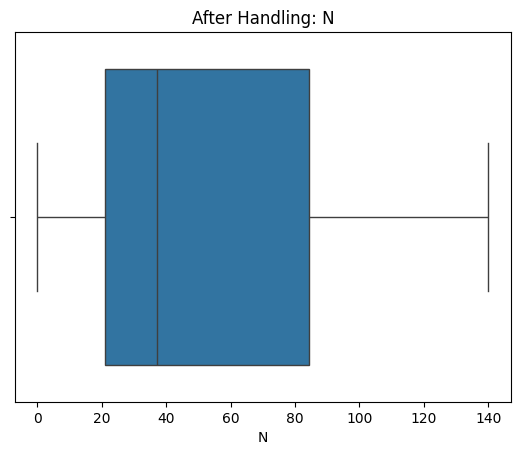

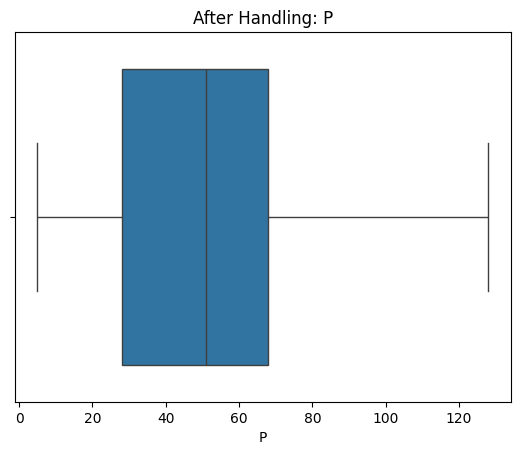

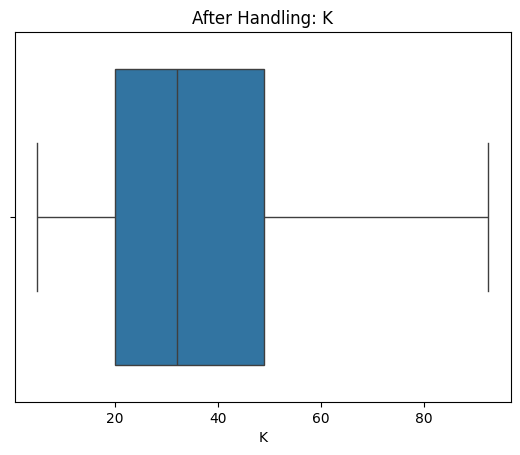

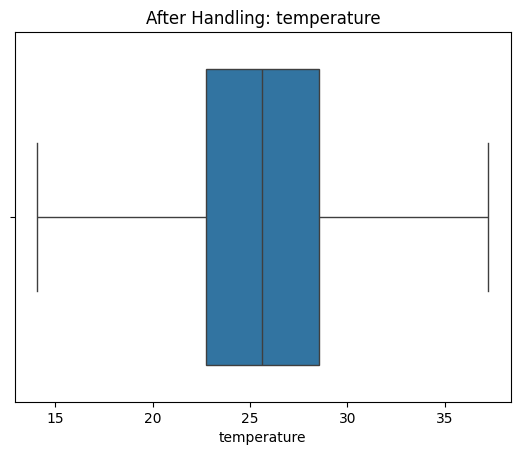

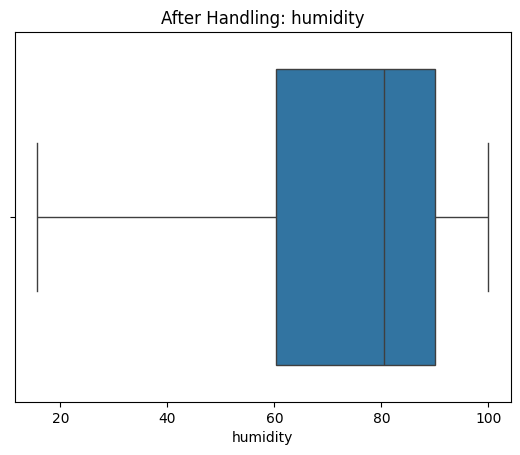

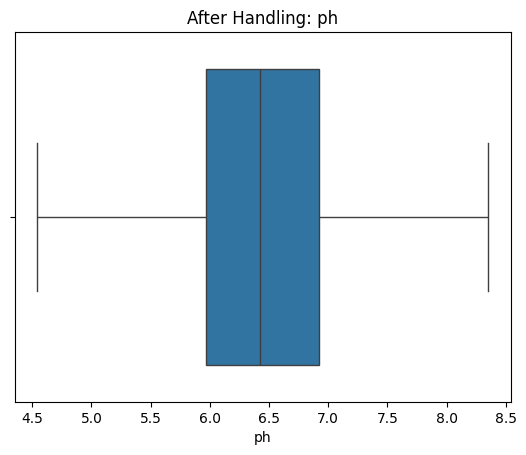

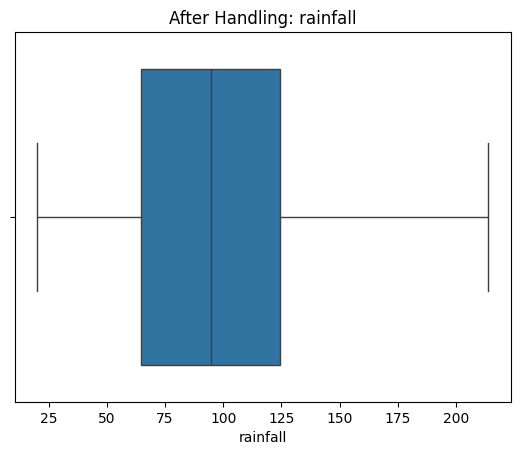

In [71]:
#setelah outlier di tangani, kembali kita cek seperti di bawah ini
for col in df.drop('label', axis=1).columns:
    sns.boxplot(x=df[col])
    plt.title(f'After Handling: {col}')
    plt.show()

In [72]:
#-encoding data kategorical
#Target label berupa teks → perlu diubah jadi angka.
#Encoding dilakukan menggunakan LabelEncoder untuk mengubah data kategorikal menjadi numerik.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Simpan mapping (penting untuk laporan)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping Label:\n", label_mapping)

Mapping Label:
 {'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


In [73]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43.0,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41.0,21.770462,80.319644,7.038096,213.841241,20
2,60,55,44.0,23.004459,82.320763,7.840207,213.841241,20
3,74,35,40.0,26.491096,80.158363,6.980401,213.841241,20
4,78,42,42.0,20.130175,81.604873,7.628473,213.841241,20
5,69,37,42.0,23.058049,83.370118,7.073454,213.841241,20
6,69,55,38.0,22.708838,82.639414,5.700806,213.841241,20
7,94,53,40.0,20.277744,82.894086,5.718627,213.841241,20
8,89,54,38.0,24.515881,83.535216,6.685346,213.841241,20
9,68,58,38.0,23.223974,83.033227,6.336254,213.841241,20


In [74]:
#Normalisasi atau standarisasi data
#karena saya menggunakan KNN, Decision Tree, Random Forest maka Scaling tetap dilakukan (karena ada KNN)
#Standarisasi dilakukan menggunakan StandardScaler untuk mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1.
# Proses ini bertujuan untuk menyamakan skala antar fitur agar model berbasis jarak seperti KNN dapat bekerja secara optimal.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target
X = df.drop('label', axis=1)
y = df['label']

# Bagi data menjadi training dan testing set (contoh: 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standarisasi
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


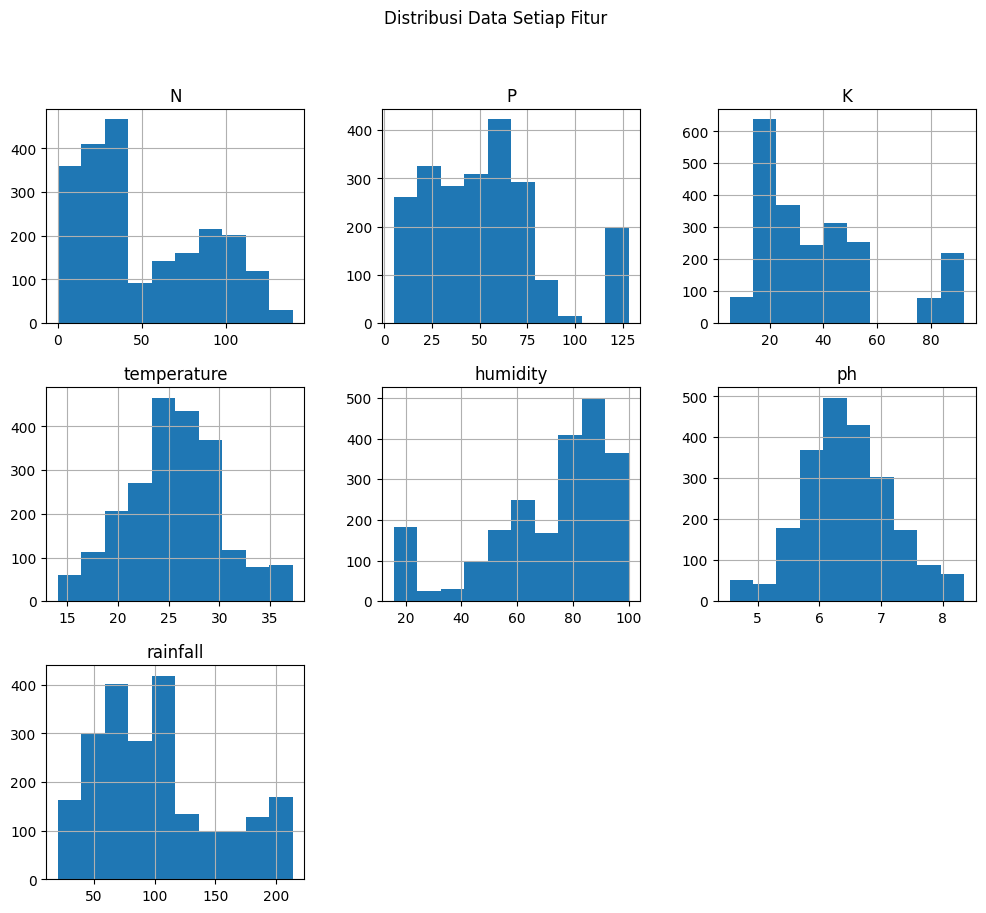

In [75]:
#3. EXPLORATORY DATA ANALYSIS (EDA)
#- melihat distribusi data
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram semua fitur
df.drop('label', axis=1).hist(figsize=(12,10))
plt.suptitle("Distribusi Data Setiap Fitur")
plt.show()

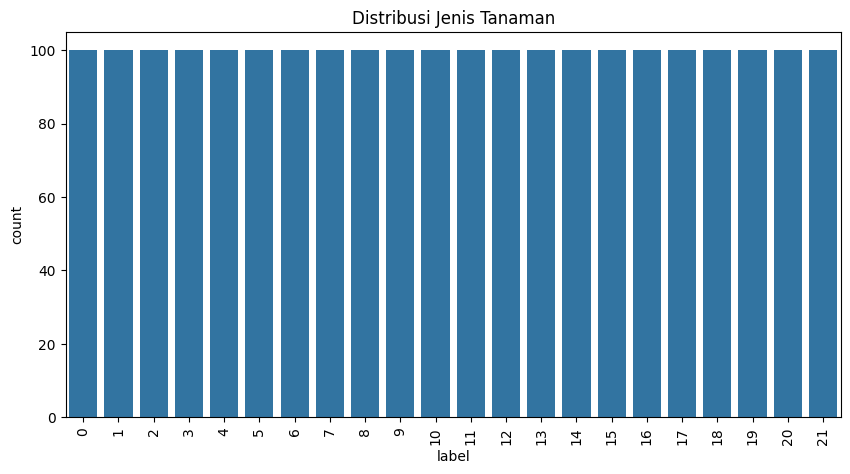

In [76]:
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Distribusi Jenis Tanaman")
plt.show()

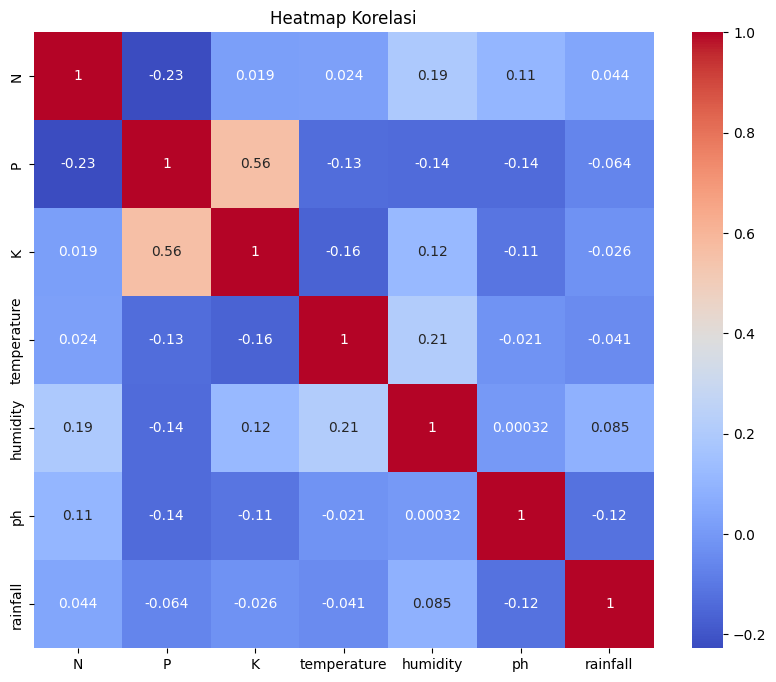

In [77]:
#korelasi antar variabel
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

In [78]:
#Pemisahan fitur (X) dan target (y) dilakukan setelah data siap (clean), sebelum splitting
X = df.drop('label', axis=1)
y = df['label']

In [79]:
#4. Data Splitting
#Membagi dataset menjadi training data dan testing data dengan minimal 3 variasi pembagian.
#1.Split 70:30
#2.split 80:20
#3.split 90:10
from sklearn.model_selection import train_test_split



In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# SPLIT 70:30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [81]:
# SPLIT 80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [82]:

# SPLIT 90:10
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

In [83]:
#5. model building
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Simpan semua split dalam dictionary
splits = {
    "70:30": (X_train_70, X_test_30, y_train_70, y_test_30),
    "80:20": (X_train_80, X_test_20, y_train_80, y_test_20),
    "90:10": (X_train_90, X_test_10, y_train_90, y_test_10)
}

# Model
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Loop semua kombinasi
for split_name, (X_train, X_test, y_train, y_test) in splits.items():
    print(f"\n=== Split {split_name} ===")

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred) * 100
        print(f"{model_name:<15}: {acc:.2f}%")


=== Split 70:30 ===
KNN            : 98.03%
Decision Tree  : 97.88%
Random Forest  : 99.39%

=== Split 80:20 ===
KNN            : 97.95%
Decision Tree  : 97.95%
Random Forest  : 99.55%

=== Split 90:10 ===
KNN            : 98.18%
Decision Tree  : 98.64%
Random Forest  : 99.09%


In [84]:
#hyperparameter tunning
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

print("=== HYPERPARAMETER TUNING (80:20) ===")

# Gunakan split terbaik
X_train = X_train_80
X_test = X_test_20
y_train = y_train_80
y_test = y_test_20


# =========================
# 1. KNN
# =========================
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3)
knn_grid.fit(X_train, y_train)

knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred) * 100

print("\nKNN")
print("Best Parameter:", knn_grid.best_params_)
print(f"Akurasi       : {knn_acc:.2f}%")


# =========================
# 2. DECISION TREE
# =========================
dt_params = {
    'max_depth': [None, 5, 10, 15, 20]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=3)
dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred) * 100

print("\nDecision Tree")
print("Best Parameter:", dt_grid.best_params_)
print(f"Akurasi       : {dt_acc:.2f}%")


# =========================
# 3. RANDOM FOREST 🔥
# =========================
rf_params =  {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred) * 100

print("\nRandom Forest 🔥")
print("Best Parameter:", rf_grid.best_params_)
print(f"Akurasi       : {rf_acc:.2f}%")

#

=== HYPERPARAMETER TUNING (80:20) ===

KNN
Best Parameter: {'n_neighbors': 3}
Akurasi       : 97.95%

Decision Tree
Best Parameter: {'max_depth': None}
Akurasi       : 97.95%

Random Forest 🔥
Best Parameter: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Akurasi       : 99.32%


Hyperparameter tuning dilakukan menggunakan metode Grid Search untuk mendapatkan kombinasi parameter terbaik. Proses ini dilakukan pada model KNN, Decision Tree, dan Random Forest. Hasil tuning menunjukkan bahwa model Random Forest dengan parameter optimal menghasilkan performa terbaik dibandingkan model lainnya.

In [85]:
#.8 Model Comparison
#Membuat tabel atau grafik yang membandingkan:
#Akurasi model
#Performa tiap algoritma
#Hasil dari setiap data splitting
import pandas as pd
from sklearn.metrics import accuracy_score

results = []

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    # Model
    models = {
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred) * 100

        results.append({
            "Split": split_name,
            "Model": model_name,
            "Accuracy (%)": acc
        })

# Buat DataFrame
df_results = pd.DataFrame(results)

print(df_results)


   Split          Model  Accuracy (%)
0  70:30            KNN     98.030303
1  70:30  Decision Tree     97.878788
2  70:30  Random Forest     99.393939
3  80:20            KNN     97.954545
4  80:20  Decision Tree     97.954545
5  80:20  Random Forest     99.545455
6  90:10            KNN     98.181818
7  90:10  Decision Tree     98.636364
8  90:10  Random Forest     99.090909



=== Split 70:30 ===


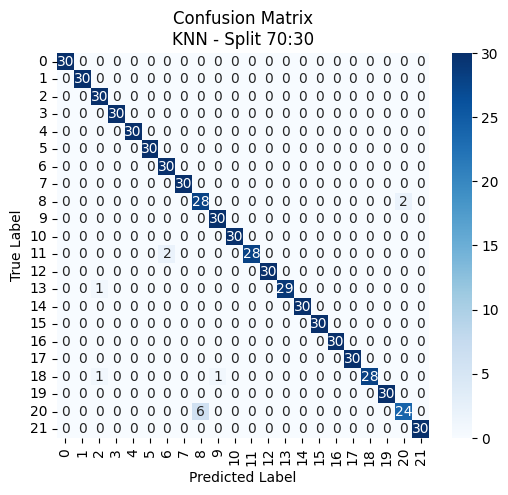

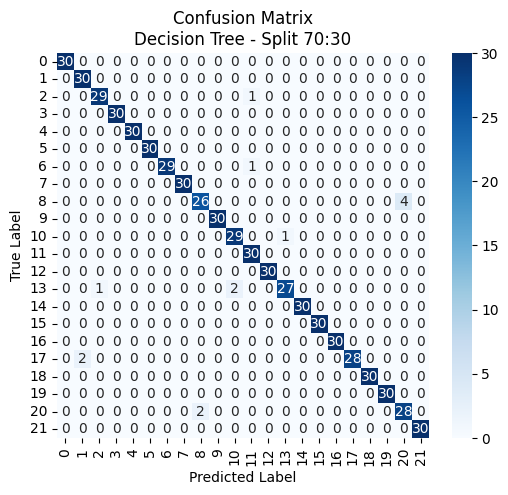

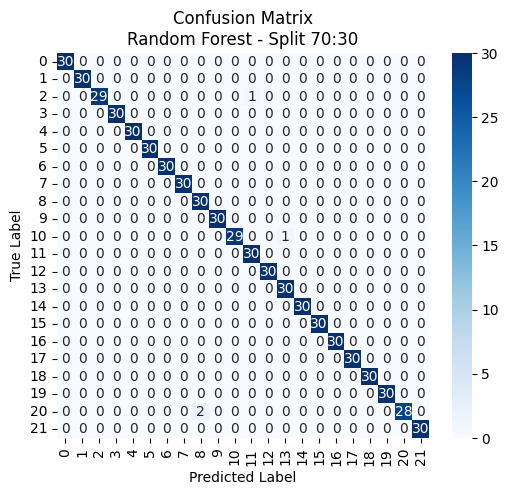


=== Split 80:20 ===


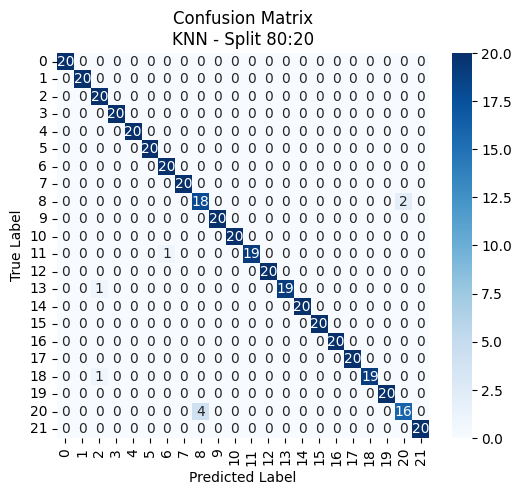

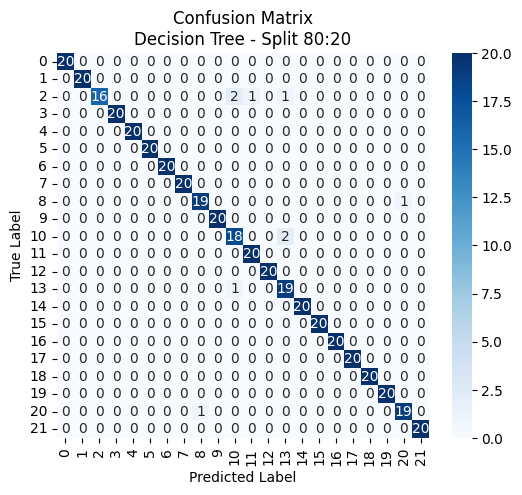

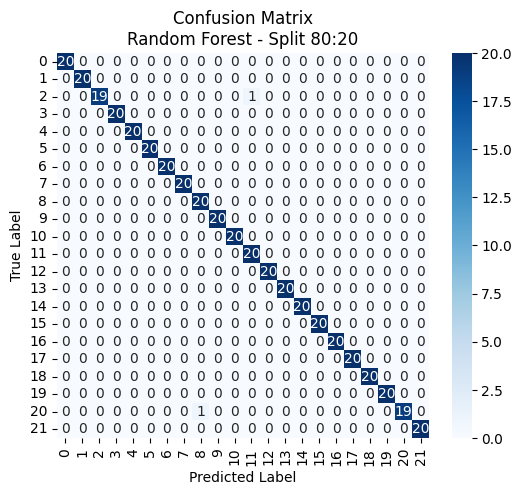


=== Split 90:10 ===


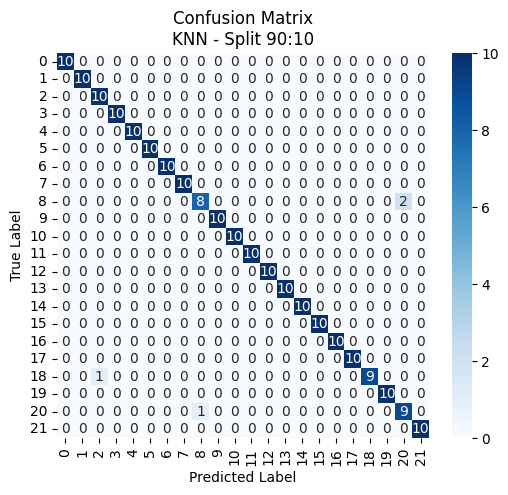

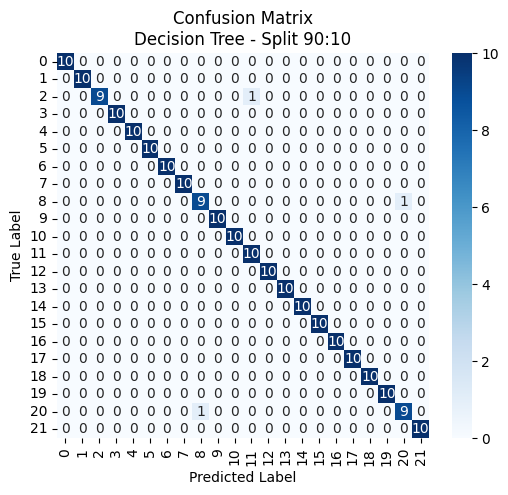

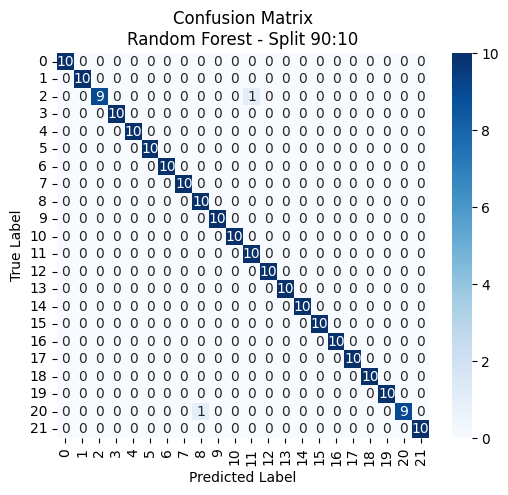

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Loop semua split
for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    print(f"\n=== Split {split_name} ===")

    models = {
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    for model_name, model in models.items():
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Hitung confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        # Visualisasi
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

        plt.title(f'Confusion Matrix\n{model_name} - Split {split_name}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')

        plt.show()

In [87]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    models = {
        "KNN": knn_best,
        "Decision Tree": dt_best,
        "Random Forest": rf_best
    }

    for model_name, model in models.items():
        # Train ulang model (opsional tapi aman)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Hitung metrik
        acc = accuracy_score(y_test, y_pred) * 100
        precision = precision_score(y_test, y_pred, average='weighted') * 100
        recall = recall_score(y_test, y_pred, average='weighted') * 100
        f1 = f1_score(y_test, y_pred, average='weighted') * 100

        # Simpan hasil
        results.append([
            model_name,
            split_name,
            acc,
            precision,
            recall,
            f1
        ])

# Buat DataFrame
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Split', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-score (%)']
)

print(results_df)

           Model  Split  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)
0            KNN  70:30     97.878788      97.973913   97.878788     97.877496
1  Decision Tree  70:30     97.878788      97.931853   97.878788     97.874320
2  Random Forest  70:30     99.393939      99.422654   99.393939     99.393518
3            KNN  80:20     97.954545      98.015234   97.954545     97.958688
4  Decision Tree  80:20     97.954545      98.059819   97.954545     97.942315
5  Random Forest  80:20     99.318182      99.350649   99.318182     99.317755
6            KNN  90:10     98.181818      98.255280   98.181818     98.177261
7  Decision Tree  90:10     98.636364      98.677686   98.636364     98.635224
8  Random Forest  90:10     99.090909      99.173554   99.090909     99.088631


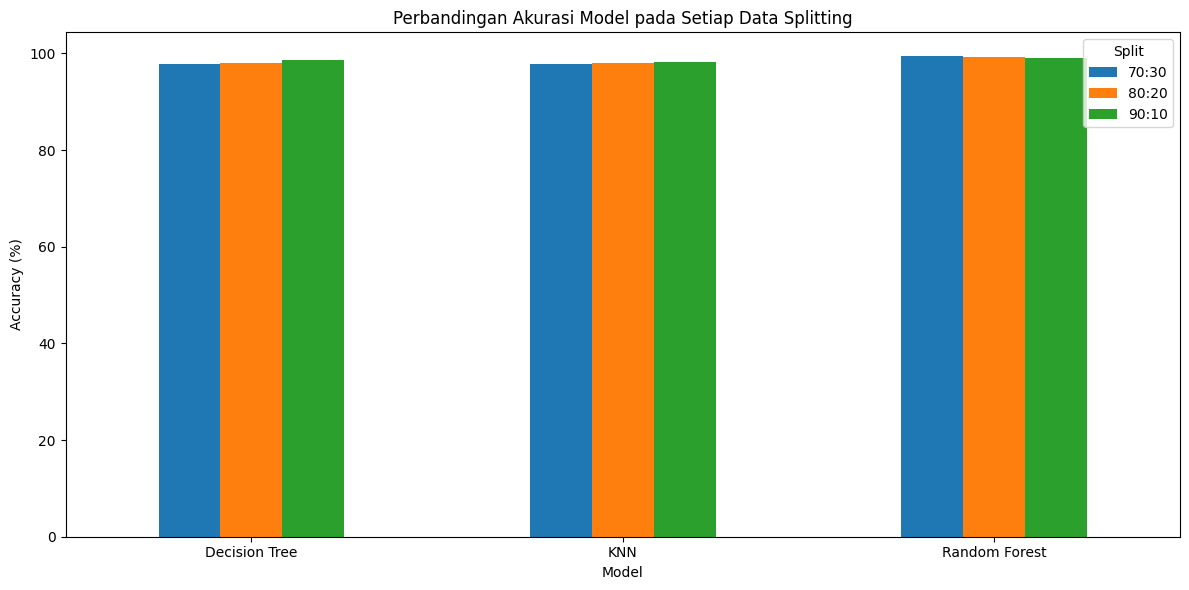

In [88]:
import matplotlib.pyplot as plt

pivot_table = results_df.pivot_table(index='Model', columns='Split', values='Accuracy (%)')

pivot_table.plot(kind='bar', figsize=(12, 6))

plt.title('Perbandingan Akurasi Model pada Setiap Data Splitting')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')

plt.xticks(rotation=0)
plt.legend(title='Split')
plt.tight_layout()
plt.show()